# Testing our equation to La Jara data 

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error
import itertools

### Model Functions

From flume data we have that: 
- $A = 0.2924$
- $B = 8.6866$
- $K_{str} = 50$
- $X_{0} = 0.79$
- $K_{wk} = 3.7$


In [2]:
def evolve_tauc_tc(
    tau_star,           # array of Shields stress τ*(t)
    dt,                 # timestep between τ* samples
    tau_c_min,          # minimum τ*c global
    tau_c_max,          # maximum τ*c global
    event_indices,      # time labels or integer positions where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    multiplicative_factor=1, # factor to adjust k values (e.g., for sensitivity testing)
    A=0.2924,
    B=8.6866,
    ks=50, # sigmoid k_strengthening
    xs=0.79, # sigmoid x_shift (tc/tc_eq at inflection point)
    kw=3.7 # sigmoid k_weakening
):

    # convert τ* to numeric 1D array and keep index if Series
    if isinstance(tau_star, pd.Series):
        tau_index = tau_star.index
        tau_star_vals = tau_star.to_numpy(dtype=float)
    else:
        tau_index = None
        tau_star_vals = np.asarray(tau_star, dtype=float)

    if tau_star_vals.ndim != 1:
        raise ValueError("tau_star must be 1D after conversion")

    # convert event indices to integer positions in tau_star_vals
    event_labels = np.asarray(event_indices)
    if tau_index is not None:
        event_pos = tau_index.get_indexer(event_labels)

        # allow an initialization observation before forcing starts (e.g., event 0 while tau index starts at 1)
        missing_mask = event_pos < 0
        if np.any(missing_mask) and np.issubdtype(event_labels.dtype, np.number):
            before_start = missing_mask & (event_labels < tau_index.min())
            event_pos[before_start] = 0

        if np.any(event_pos < 0):
            missing_labels = event_labels[event_pos < 0]
            raise ValueError(f"some event indices are not in tau_star index: {missing_labels}")
    else:
        event_pos = np.asarray(event_indices, dtype=int)

    # keep only observed τ*c values that are not NaN
    tau_c_obs_arr = np.asarray(tau_c_obs, dtype=float)
    valid_obs_mask = ~np.isnan(tau_c_obs_arr)
    event_pos_valid = event_pos[valid_obs_mask]
    tau_c_obs_valid = tau_c_obs_arr[valid_obs_mask]

    # initialize modeled τ*c, τ*c_eq, and k array
    n = len(tau_star_vals)
    tau_c = np.full(n, np.nan, dtype=float)  # nan means τ*c is undefined (e.g., during gaps)
    tau_c_pot = np.full(n, np.nan, dtype=float)
    k_array = np.full(n, np.nan, dtype=float)
    tauc_ratio = np.full(n, np.nan, dtype=float)
    tau_conv_array = np.full(n, np.nan, dtype=float)

    tau_c_obs_dict = dict(zip(event_pos_valid, tau_c_obs_valid))
    was_in_gap = True

    i = 0
    while i < n-1:
        # determine current τ*
        t = tau_star_vals[i]  # current τ*

        # k equation parameters from flume data
        k = A * (t / tau_c_max) ** B

        # initialize τ*c when observation exists
        if was_in_gap and i in tau_c_obs_dict:
            tau_c_current = tau_c_obs_dict[i]
            tau_c[i] = tau_c_current
            was_in_gap = False
        else:
            tau_c_current = tau_c[i]

        # calculate transport capacity 
        tc = t/tau_c_current  # transport capacity
        tauc_ratio[i] = tc

        # calculate potential τ*c based on current τ*/τ*c
        if tc <= 1:
            sigmoid_0 = 1 / (1 + np.exp(-ks * (0 - xs)))
            sigmoid_1 = 1 / (1 + np.exp(-ks * (1 - xs)))
            sigmoig_tc = 1 / (1 + np.exp(-ks * (tc - xs)))
            sigmoid = (sigmoig_tc - sigmoid_0) / (sigmoid_1 - sigmoid_0)
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) * sigmoid 
            tau_pot = max(tau_c_current, tau_conv)  # τ*c cannot decrease below current value if τ* is low
            tau_pot_pure = tau_conv
        else:  # otherwise, equilibrium is given by the weakening function
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) * (tc) ** (-kw)
            tau_pot = tau_conv
            tau_pot_pure = tau_conv

        k_array[i] = k
        tau_c_pot[i] = tau_pot_pure
        tau_conv_array[i] = tau_pot

        # evolve τ*c with new equation
        tau_c[i+1] = tau_conv_array[i] - (tau_conv_array[i] - tau_c[i]) * np.exp(-k * multiplicative_factor * dt)
        #print('tauc at time:', i, 'is', tau_c[i], '. tau/tauc', tauc_ratio[i], 'and tau_pot is', tau_c_pot[i], 'with k', k_array[i])
        i += 1

    return tau_c, k_array, tau_c_pot, tauc_ratio

parameter calibration 

In [3]:
def calibrate_parameters(
    tau_star,
    event_indices,
    tau_c_obs,
    dt,
    tau_c_max,
    tau_c_min,
    A_vals,
    B_vals,
    ks_vals,
    kw_vals,
    xs=0.79
):
    """
    Grid-search calibration of the model using mean absolute error (MAE).
    """
    results = []
    tau_c_obs_arr = np.asarray(tau_c_obs, dtype=float)

    for A_idx, A in enumerate(A_vals):
        print(f"Testing A = {A:.6e} ({A_idx + 1}/{len(A_vals)})")
        for B_idx, B in enumerate(B_vals):
            print(f"Testing B = {B:.6e} ({B_idx + 1}/{len(B_vals)})")
            for ks_idx, ks in enumerate(ks_vals):
                print(f"Testing ks = {ks:.6e} ({ks_idx + 1}/{len(ks_vals)})")
                for kw_idx, kw in enumerate(kw_vals):
                    print(f"Testing kw = {kw:.6e} ({kw_idx + 1}/{len(kw_vals)})")

                    tau_c_model, *_ = evolve_tauc_tc(
                        tau_star=tau_star,
                        dt=dt,
                        tau_c_min=tau_c_min,
                        tau_c_max=tau_c_max,
                        event_indices=event_indices,
                        tau_c_obs=tau_c_obs,
                        A=A,
                        B=B,
                        ks=ks,
                        xs=xs,
                        kw=kw,
                    )

                    if isinstance(tau_star, pd.Series):
                        tau_c_series = pd.Series(tau_c_model, index=tau_star.index)
                        tau_c_pred = tau_c_series.reindex(event_indices).to_numpy(dtype=float)
                    else:
                        event_pos = np.asarray(event_indices, dtype=int)
                        tau_c_pred = np.asarray(tau_c_model, dtype=float)[event_pos]

                    mae = np.nanmean(np.abs(tau_c_pred - tau_c_obs_arr))
                    results.append({
                        "A": A,
                        "B": B,
                        "ks": ks,
                        "kw": kw,
                        "MAE": mae,
                    })

    expected = len(A_vals) * len(B_vals) * len(ks_vals) * len(kw_vals)
    if len(results) != expected:
        raise RuntimeError(f"Expected {expected} calibration rows, got {len(results)}")

    return results

### First Iteration: Using all data points

Import Data

In [4]:
# import data 
tau_star = pd.read_csv('../../../shear_stress_record/average_shear_stress_lajara_full.csv')
tauc_events = pd.read_csv('../field_data/tauc_events_exceedance_rising.csv', parse_dates=['datetime'], index_col='datetime')
# convert to datetime and set as index
tau_star['datetime'] = pd.to_datetime(tau_star['datetime']) 
tau_star = tau_star.set_index('datetime')

# change column name to 'tau' for clarity
df_tau_resampled = tau_star.rename(columns={'shear_stress': 'tau'})
# delete everything before 2022-07-14 (we don't care about earlier times)
df_tau_resampled = df_tau_resampled[df_tau_resampled.index >= '2022-07-14 15:00']

print(f"Data gaps (NaNs): {df_tau_resampled['tau'].isna().sum().sum()}")
# show what dates are the data gaps
print("Data gaps (NaN indices):", df_tau_resampled[df_tau_resampled['tau'].isna()].index)

# convert tau to dimenstionless Shields stress τ*
rho_s = 2650.0  # sediment density, kg/m3
rho = 1000.0   # fluid density, kg/m3
g = 9.81       # gravitational acceleration, m/s2
d50 = 0.04364    # median grain diameter, m

df_tau_resampled['tau_star'] = df_tau_resampled['tau'] / ((rho_s - rho) * g * d50)

# build integer index mapping
time_to_index = pd.Series(
    np.arange(len(df_tau_resampled)), 
    index=df_tau_resampled.index
)
event_indices = time_to_index.loc[tauc_events.index].to_numpy() # integer indices of event times
tau_c_obs = tauc_events["tauc"].to_numpy() # observed τ*c values
tau_star = df_tau_resampled["tau_star"].to_numpy() # τ* time series array

# calculate dt in minutes (should be 15)
dt = (df_tau_resampled.index[1] - df_tau_resampled.index[0]).total_seconds() / 60
print(f"Calculated dt: {dt} minutes")

Data gaps (NaNs): 0
Data gaps (NaN indices): DatetimeIndex([], dtype='datetime64[ns]', name='datetime', freq=None)
Calculated dt: 15.0 minutes


- $\tau_{c,max} = 0.133400673$
- $\tau_{c,min} = 0.071856367$

In [5]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 20)   
B_vals = np.linspace(1, 20, 15)   
ks_vals = np.linspace(1, 100, 15) 
kw_vals = np.linspace(1, 100, 15) 

tauc_max_lajara = 0.133400673
tauc_min_lajara = 0.071856367
tauc_obs_lajara = tauc_events["tauc"].to_numpy()

In [6]:
tauc_max_lajara

0.133400673

In [7]:
calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=15,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
    ks_vals=ks_vals,
    kw_vals=kw_vals,
    xs=0.79
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/20)
Testing B = 1.000000e+00 (1/15)
Testing ks = 1.000000e+00 (1/15)
Testing kw = 1.000000e+00 (1/15)
Testing kw = 8.071429e+00 (2/15)
Testing kw = 1.514286e+01 (3/15)
Testing kw = 2.221429e+01 (4/15)
Testing kw = 2.928571e+01 (5/15)
Testing kw = 3.635714e+01 (6/15)
Testing kw = 4.342857e+01 (7/15)
Testing kw = 5.050000e+01 (8/15)
Testing kw = 5.757143e+01 (9/15)
Testing kw = 6.464286e+01 (10/15)
Testing kw = 7.171429e+01 (11/15)
Testing kw = 7.878571e+01 (12/15)
Testing kw = 8.585714e+01 (13/15)
Testing kw = 9.292857e+01 (14/15)
Testing kw = 1.000000e+02 (15/15)
Testing ks = 8.071429e+00 (2/15)
Testing kw = 1.000000e+00 (1/15)
Testing kw = 8.071429e+00 (2/15)
Testing kw = 1.514286e+01 (3/15)
Testing kw = 2.221429e+01 (4/15)
Testing kw = 2.928571e+01 (5/15)
Testing kw = 3.635714e+01 (6/15)
Testing kw = 4.342857e+01 (7/15)
Testing kw = 5.050000e+01 (8/15)
Testing kw = 5.757143e+01 (9/15)
Testing kw = 6.464286e+01 (10/15)
Testing kw = 7.171429e+01 (11/15)
Test

Plot

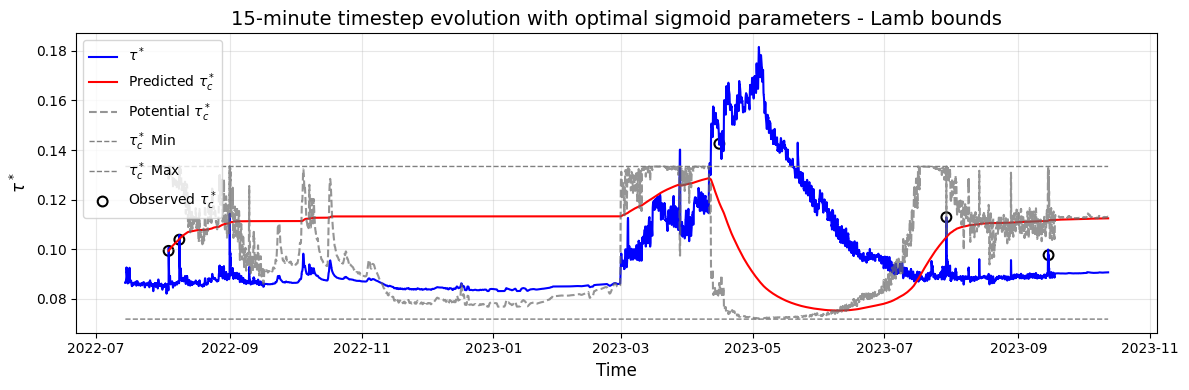

In [9]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=15, # 1 minute timestep
    tau_c_min=tauc_min_lajara,
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
    ks=best["ks"],
    kw=best["kw"],
    xs=0.79
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [tauc_min_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("15-minute timestep evolution with optimal sigmoid parameters - Lamb bounds", fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.009221
10% threshold (<=): 0.009682
Parameter sets within threshold: 18 / 67500


,A,B,MAE,ks,kw
0,0.000038,1.0,0.009221,43.428571,8.071429
1,0.000038,1.0,0.009222,50.500000,8.071429
2,0.000038,1.0,0.009232,57.571429,8.071429
3,0.000038,1.0,0.009245,64.642857,8.071429
4,0.000038,1.0,0.009258,71.714286,8.071429
5,0.000038,1.0,0.009271,78.785714,8.071429
6,0.000038,1.0,0.009275,36.357143,8.071429
7,0.000038,1.0,0.009283,85.857143,8.071429
8,0.000038,1.0,0.009293,92.928571,8.071429
9,0.000038,1.0,0.009302,100.000000,8.071429


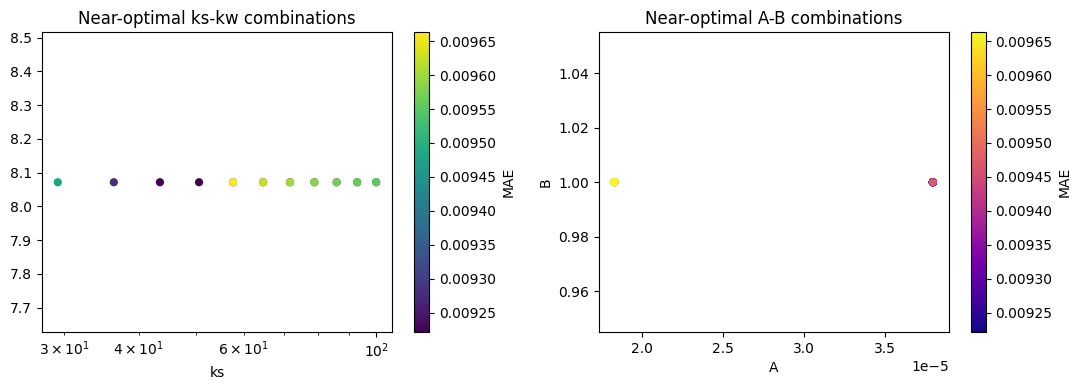

In [10]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)
mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.05

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "dt=15/6_observed_range_A_b_ks_kw_lambbounds.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "ks", "kw"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["ks"],
        near_optimal["kw"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("ks")

    axes[0].set_title("Near-optimal ks-kw combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("A")
    axes[1].set_ylabel("B")
    axes[1].set_title("Near-optimal A-B combinations")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label(mae_col)

    plt.tight_layout()
    plt.show()

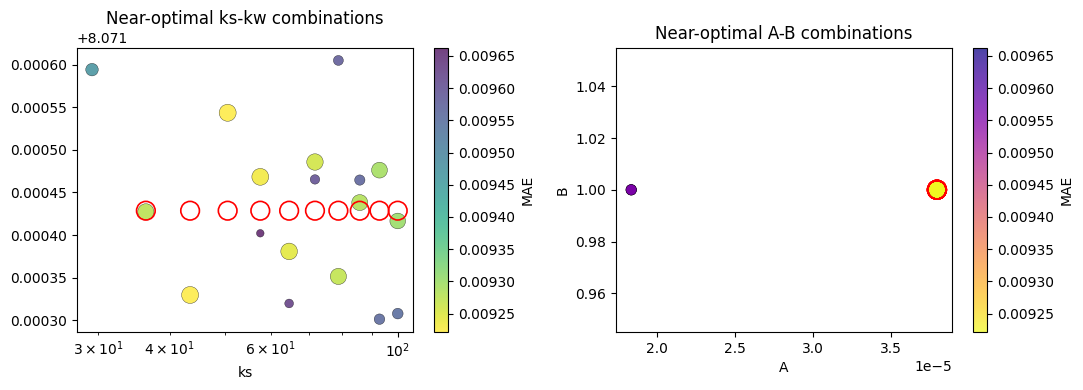

In [11]:
import matplotlib as mpl
near = near_optimal.copy()

# draw high MAE first so low MAE (best) plot on top
near = near.sort_values(mae_col, ascending=False)

# tiny jitter to separate exact duplicates (adjust scale if needed)
jitter = 1e-6 * (near["ks"].median() if "ks" in near.columns else 1)
ks_j = near["ks"] + np.random.normal(0, jitter, size=len(near))
kw_j = near["kw"] + np.random.normal(0, jitter, size=len(near))

# size: inverse MAE -> larger for better fits
mae_min, mae_max = near[mae_col].min(), near[mae_col].max()
size = 30 + (mae_max - near[mae_col]) / (mae_max - mae_min + 1e-12) * 120

norm = mpl.colors.Normalize(vmin=mae_min, vmax=mae_max)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sc1 = axes[0].scatter(
    ks_j, kw_j,
    c=near[mae_col],
    cmap="viridis_r",  # reversed so low MAE = bright
    norm=norm,
    s=size,
    alpha=0.75,
    edgecolors="k",
    linewidths=0.3,
)
axes[0].set_xscale("log")
axes[0].set_xlabel("ks")
axes[0].set_title("Near-optimal ks-kw combinations")
cbar1 = plt.colorbar(sc1, ax=axes[0])
cbar1.set_label(mae_col)

# A-B panel
if {"A", "B"}.issubset(near.columns):
    sc2 = axes[1].scatter(
        near["A"], near["B"],
        c=near[mae_col],
        cmap="plasma_r",
        norm=norm,
        s=size,
        alpha=0.75,
        edgecolors="k",
        linewidths=0.3,
    )
    axes[1].set_xlabel("A")
    axes[1].set_ylabel("B")
    axes[1].set_title("Near-optimal A-B combinations")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label(mae_col)

# highlight top 10 best (smallest MAE)
topN = near.nsmallest(10, mae_col)
axes[0].scatter(topN["ks"], topN["kw"], s=180, facecolors="none", edgecolors="red", linewidths=1.2, label="Top 10")
if {"A", "B"}.issubset(topN.columns):
    axes[1].scatter(topN["A"], topN["B"], s=180, facecolors="none", edgecolors="red", linewidths=1.2)

#axes[0].legend(loc="upper right", fontsize="small")
plt.tight_layout()
plt.show()

In [12]:
near_optimal["kw"].min()

np.float64(8.071428571428571)

In [13]:
near_optimal["ks"].min()

np.float64(29.285714285714285)

### Second Iteration: No ST7


In [5]:
# import data 
tau_star = pd.read_csv('../../../shear_stress_record/average_shear_stress_lajara_full.csv')
tauc_events = pd.read_csv('../field_data/tauc_events_exceedance_rising_nost7.csv', parse_dates=['datetime'], index_col='datetime')
# convert to datetime and set as index
tau_star['datetime'] = pd.to_datetime(tau_star['datetime']) 
tau_star = tau_star.set_index('datetime')

# change column name to 'tau' for clarity
df_tau_resampled = tau_star.rename(columns={'shear_stress': 'tau'})
# delete everything before 2022-07-14 (we don't care about earlier times)
df_tau_resampled = df_tau_resampled[df_tau_resampled.index >= '2022-07-14 15:00']

print(f"Data gaps (NaNs): {df_tau_resampled['tau'].isna().sum().sum()}")
# show what dates are the data gaps
print("Data gaps (NaN indices):", df_tau_resampled[df_tau_resampled['tau'].isna()].index)

# convert tau to dimenstionless Shields stress τ*
rho_s = 2650.0  # sediment density, kg/m3
rho = 1000.0   # fluid density, kg/m3
g = 9.81       # gravitational acceleration, m/s2
d50 = 0.04364    # median grain diameter, m

df_tau_resampled['tau_star'] = df_tau_resampled['tau'] / ((rho_s - rho) * g * d50)

# build integer index mapping
time_to_index = pd.Series(
    np.arange(len(df_tau_resampled)), 
    index=df_tau_resampled.index
)
event_indices = time_to_index.loc[tauc_events.index].to_numpy() # integer indices of event times
tau_c_obs = tauc_events["tauc"].to_numpy() # observed τ*c values
tau_star = df_tau_resampled["tau_star"].to_numpy() # τ* time series array

# calculate dt in minutes (should be 15)
dt = (df_tau_resampled.index[1] - df_tau_resampled.index[0]).total_seconds() / 60
print(f"Calculated dt: {dt} minutes")

Data gaps (NaNs): 0
Data gaps (NaN indices): DatetimeIndex([], dtype='datetime64[ns]', name='datetime', freq=None)
Calculated dt: 15.0 minutes


- $\tau_{c,max} = 0.133400673$
- $\tau_{c,min} = 0.071856367$

In [6]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 20)   
B_vals = np.linspace(1, 20, 15)   
ks_vals = np.linspace(1, 100, 15) 
kw_vals = np.linspace(1, 100, 15) 

tauc_max_lajara = 0.133400673
tauc_min_lajara = 0.071856367
tauc_obs_lajara = tauc_events["tauc"].to_numpy()

In [7]:
calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=15,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
    ks_vals=ks_vals,
    kw_vals=kw_vals,
    xs=0.79
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/20)
Testing B = 1.000000e+00 (1/15)
Testing ks = 1.000000e+00 (1/15)
Testing kw = 1.000000e+00 (1/15)
Testing kw = 8.071429e+00 (2/15)
Testing kw = 1.514286e+01 (3/15)
Testing kw = 2.221429e+01 (4/15)
Testing kw = 2.928571e+01 (5/15)
Testing kw = 3.635714e+01 (6/15)
Testing kw = 4.342857e+01 (7/15)
Testing kw = 5.050000e+01 (8/15)
Testing kw = 5.757143e+01 (9/15)
Testing kw = 6.464286e+01 (10/15)
Testing kw = 7.171429e+01 (11/15)
Testing kw = 7.878571e+01 (12/15)
Testing kw = 8.585714e+01 (13/15)
Testing kw = 9.292857e+01 (14/15)
Testing kw = 1.000000e+02 (15/15)
Testing ks = 8.071429e+00 (2/15)
Testing kw = 1.000000e+00 (1/15)
Testing kw = 8.071429e+00 (2/15)
Testing kw = 1.514286e+01 (3/15)
Testing kw = 2.221429e+01 (4/15)
Testing kw = 2.928571e+01 (5/15)
Testing kw = 3.635714e+01 (6/15)
Testing kw = 4.342857e+01 (7/15)
Testing kw = 5.050000e+01 (8/15)
Testing kw = 5.757143e+01 (9/15)
Testing kw = 6.464286e+01 (10/15)
Testing kw = 7.171429e+01 (11/15)
Test

Plot

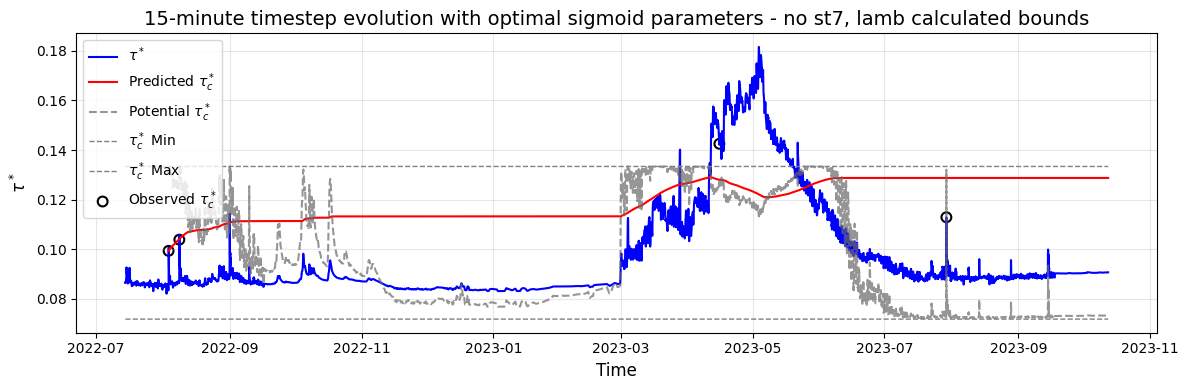

In [8]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=15, # 1 minute timestep
    tau_c_min=tauc_min_lajara,
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
    ks=best["ks"],
    kw=best["kw"],
    xs=0.79
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [tauc_min_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("15-minute timestep evolution with optimal sigmoid parameters - no st7, lamb calculated bounds", fontsize=14)

plt.tight_layout()
plt.show()

In [10]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)
mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.2

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "dt=15/8_sigmoid_params_iteration_lambbounds_nost7.csv"
near_optimal.to_csv(out_path, index=False)

Best MAE: 0.007632
10% threshold (<=): 0.009159
Parameter sets within threshold: 214 / 67500

Top 30 by MAE:


,A,B,MAE,ks,kw
0,0.000038,1.000000,0.007632,43.428571,1.000000
1,0.000038,1.000000,0.007637,36.357143,1.000000
2,0.000038,1.000000,0.007664,50.500000,1.000000
3,0.000038,1.000000,0.007691,57.571429,1.000000
4,0.000038,1.000000,0.007713,64.642857,1.000000
5,0.000038,1.000000,0.007730,71.714286,1.000000
6,0.000038,1.000000,0.007740,1.000000,1.000000
7,0.000038,1.000000,0.007744,78.785714,1.000000
8,0.000038,1.000000,0.007755,85.857143,1.000000
9,0.000038,1.000000,0.007762,29.285714,1.000000
